## Задание

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 – ошибки MSE**<0.034** на скорости обучения **0.001** на **10-й эпохе**.

## Импорт библиотек


In [ ]:
# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# Слои
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2DTranspose, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Модель
from tensorflow.keras import Model

# Загрузка модели
from tensorflow.keras.models import load_model

# Датасет
from tensorflow.keras.datasets import mnist

# Оптимизатор для обучения модели
from tensorflow.keras.optimizers import Adam

# Коллбэки для выдачи информации в процессе обучения
from tensorflow.keras.callbacks import LambdaCallback

%matplotlib inline

## Утилиты

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве

In [ ]:
def ae_on_epoch_end(epoch, logs):
    print('________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {logs["loss"]} ***')
    print('________________________')

    # Получение картинки латентного пространства в конце эпохи и запись в файл
    # Задание числа пикселей на дюйм
    plt.figure(dpi=100)

    # Предсказание енкодера на тренировочной выборке
    predict = encoder.predict(X_train)

    # Создание рисунка: множество точек на плоскости 3-х цветов (3-х классов)
    scatter = plt.scatter(predict[:,0,],predict[:,1], c=y_train, alpha=0.6, s=5)

    # Создание легенды
    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение картинки с названием, которого еще нет
    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    # Отображение. Без него рисунок не отрисуется
    plt.show()


ae_callback = LambdaCallback(on_epoch_end=ae_on_epoch_end)

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [ ]:
def clean():
  # Получение названий всех картинок
  paths = glob.glob('*.jpg')

  # Удаление всех картинок по полученным путям
  for p in paths:
    os.remove(p)

# Удаление всех картинок
clean()

## Загрузка данных

In [ ]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Нормировка
X_train = X_train.astype('float32')/255.
X_train = X_train.reshape(-1, 28, 28, 1)

In [ ]:
# Выбор визуализируемых классов (цифр) и формирование подвыборок для них по маске
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

## Создание модели и обучение

In [ ]:
# Создание модели автокодировщика с 2-мерным скрытым пространством
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam

def create_2d_autoencoder():
    img_input = Input(shape=(28, 28, 1))

    # Энкодер
    x = Flatten()(img_input)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    latent_space = Dense(2, name='latent_space')(x)

    # Декодер
    x = Dense(128, activation='relu')(latent_space)
    x = Dense(256, activation='relu')(x)
    x = Dense(28 * 28, activation='sigmoid')(x)
    outputs = Reshape((28, 28, 1))(x)

    model = Model(inputs=img_input, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

autoencoder = create_2d_autoencoder()
encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('latent_space').output)

## Обучение модели

Epoch 1/10
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1339________________________
*** ЭПОХА: 1, loss: 0.09086571633815765 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


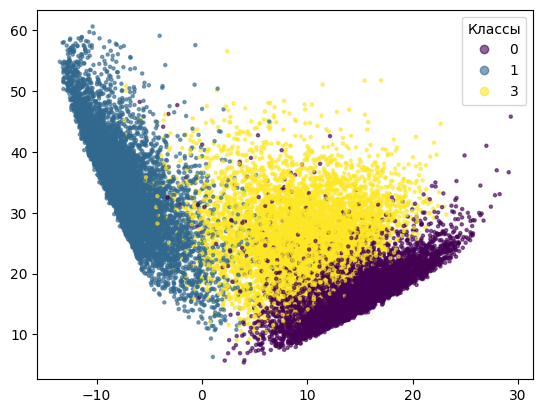

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0909
Epoch 2/10
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0519________________________
*** ЭПОХА: 2, loss: 0.04862745851278305 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


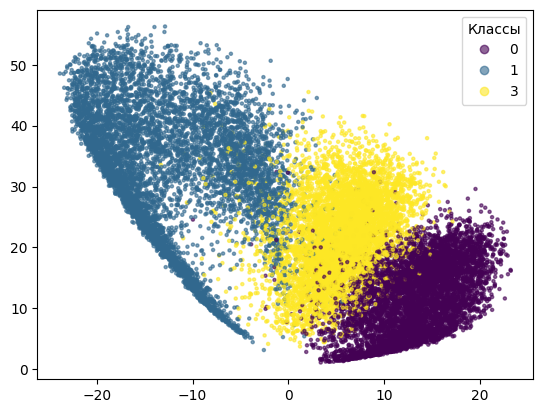

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0486
Epoch 3/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0409________________________
*** ЭПОХА: 3, loss: 0.03989322856068611 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


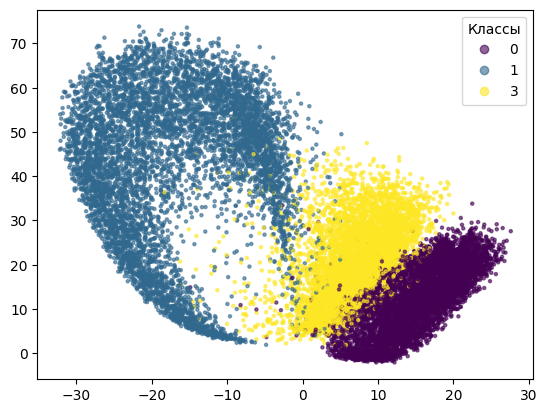

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0399
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0377________________________
*** ЭПОХА: 4, loss: 0.03721809759736061 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


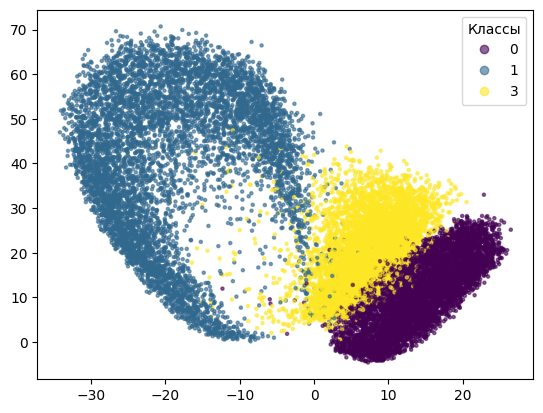

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0372
Epoch 5/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0364________________________
*** ЭПОХА: 5, loss: 0.0362376943230629 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


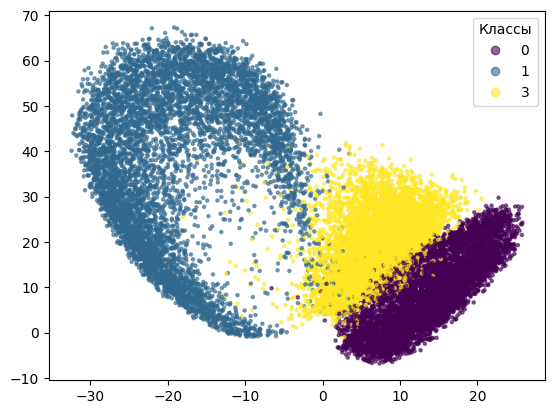

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0362
Epoch 6/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0356________________________
*** ЭПОХА: 6, loss: 0.03556794673204422 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


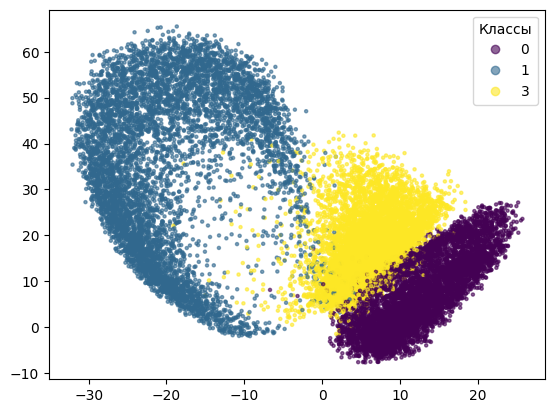

74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 0.0356
Epoch 7/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0349________________________
*** ЭПОХА: 7, loss: 0.03494906798005104 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


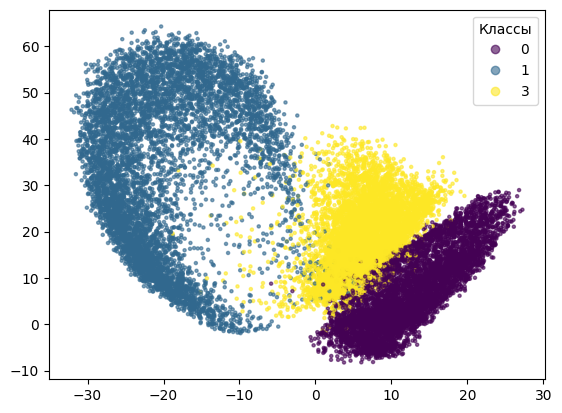

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0349
Epoch 8/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0345________________________
*** ЭПОХА: 8, loss: 0.034361060708761215 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


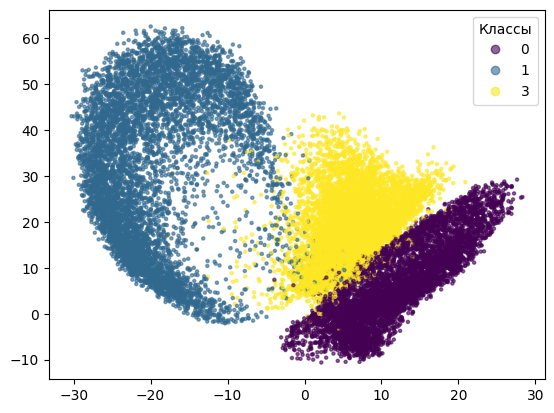

74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0344
Epoch 9/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0341________________________
*** ЭПОХА: 9, loss: 0.033915288746356964 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


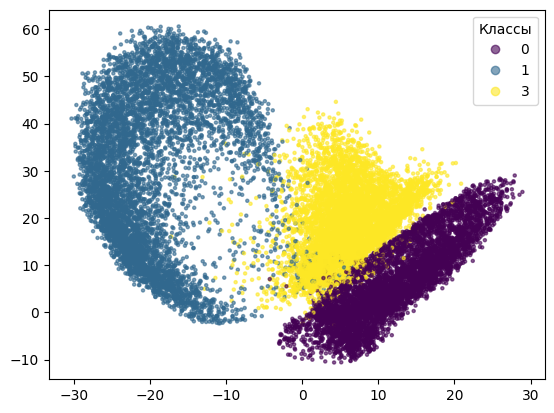

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0339
Epoch 10/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0335________________________
*** ЭПОХА: 10, loss: 0.03344922512769699 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


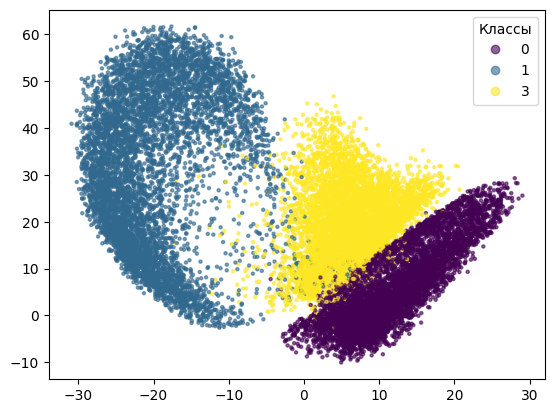

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.0334


In [ ]:
# Обучение модели
history = autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=256,
    verbose=1,
    callbacks=[ae_callback]
)

## Получение предсказания и расчет MSE

In [ ]:
# Получение предсказаний и расчет MSE
predictions = autoencoder.predict(X_train)
mse = np.mean((X_train - predictions) ** 2)
print(f'MSE на 10-й эпохе: {mse:.6f}')

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MSE на 10-й эпохе: 0.033212


## Визуализация оригиналов и реконструкций

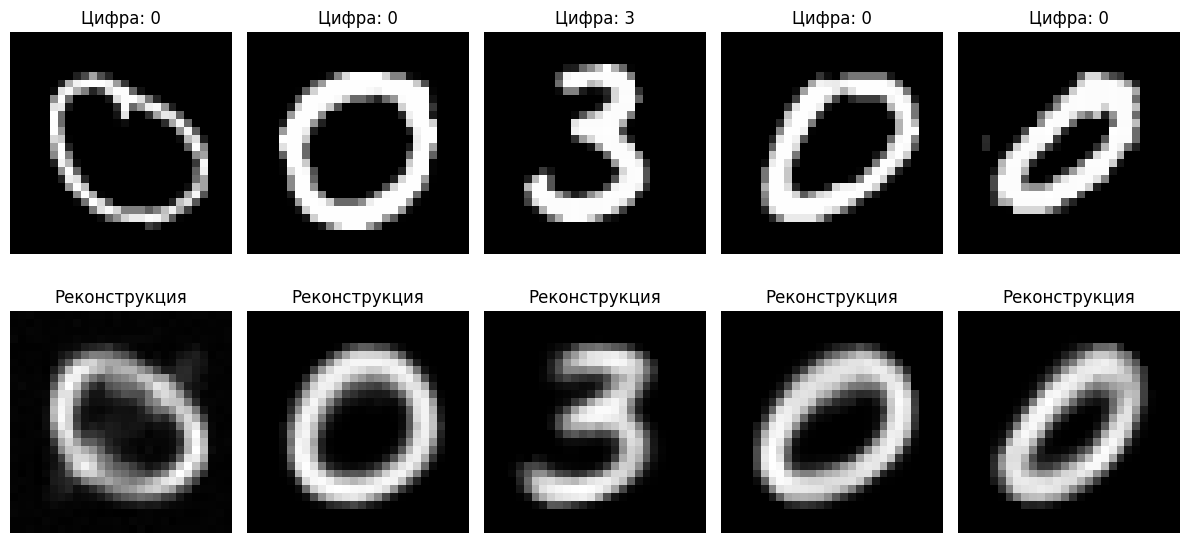

In [ ]:
# Визуализация оригиналов и реконструкций
plt.figure(figsize=(12, 6))
n = 5
for i in range(n):
    idx = np.random.randint(0, len(X_train))

    plt.subplot(2, n, i+1)
    plt.imshow(X_train[idx].squeeze(), cmap='gray')
    plt.title(f'Цифра: {y_train[idx]}')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(predictions[idx].squeeze(), cmap='gray')
    plt.title('Реконструкция')
    plt.axis('off')
plt.tight_layout()
plt.show()